# Cross-Species Fruit Quality Grading via Few-Shot Prototypical Networks

**Author:** Amr Samir  
**Master's Thesis – 2026**

---

**Research Gap:** While models can classify fruit species, they fail to generalize quality grading (Good/Bad) across unseen fruit types.  
**Key Contribution:** Train on {Apple, Banana, Grape} → Test on {Mango, Orange} WITHOUT retraining.

In [1]:
import os, sys, random, warnings
import numpy as np
import torch
warnings.filterwarnings('ignore')

# Ensure the repo root is on the path so `src` and `config` are importable
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from config import Config, ensure_dirs
from src.transforms import build_transforms
from src.dataset import FruitQualityDataset, EpisodicDataLoader
from src.models import PrototypicalNetwork
from src.losses import PrototypicalLoss
from src.train import train_protonet, evaluate, load_checkpoint
from src.visualization import (
    plot_training_history, visualize_embeddings,
    plot_confusion_matrices, plot_ablation_nshot,
)
from src.experiments import (
    test_on_unseen_fruits, ablation_n_shot,
    run_all_fsl_baselines, backbone_ablation,
    run_single_species_baselines,
    species_split_cross_validation,
    statistical_significance_tests,
    component_ablation,
    collect_dataset_statistics,
    generate_thesis_summary, generate_latex_tables,
)

# ── Reproducibility ──
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

config = Config()
ensure_dirs(config)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.5.1+cu121


## 1 · Dataset Statistics

In [2]:
dataset_stats = collect_dataset_statistics(
    config.DATA_ROOT, config.TRAIN_FRUITS, config.TEST_FRUITS, config.CLASSES
)

DATASET STATISTICS

TRAINING SET (Seen Fruits):
--------------------------------------------------
  APPLE: fresh: 765 | rotten: 630
  BANANA: fresh: 749 | rotten: 632
  GRAPE: fresh: 770 | rotten: 630

  TOTAL TRAINING: 4176 images

TEST SET (Unseen Fruits):
--------------------------------------------------
  MANGO: fresh: 763 | rotten: 630
  ORANGE: fresh: 753 | rotten: 656

  TOTAL TEST: 2802 images

SUMMARY: 6978 total images (train: 4176, test: 2802) | Fresh: 3800, Rotten: 3178


## 2 · Build Transforms & Datasets

In [3]:
transforms_dict = build_transforms(config)
train_transform   = transforms_dict['train']
support_transform = transforms_dict['support']
eval_transform    = transforms_dict['eval']

# Training & validation (seen fruits)
train_dataset = FruitQualityDataset(
    config.DATA_ROOT, config.TRAIN_FRUITS,
    support_transform=support_transform, query_transform=train_transform,
    split='train', val_ratio=config.VAL_SPLIT_RATIO, seed=42,
)
val_dataset = FruitQualityDataset(
    config.DATA_ROOT, config.TRAIN_FRUITS,
    support_transform=eval_transform, query_transform=eval_transform,
    split='val', val_ratio=config.VAL_SPLIT_RATIO, seed=42,
)

# Test (unseen fruits)
test_dataset = FruitQualityDataset(
    config.DATA_ROOT, config.TEST_FRUITS,
    support_transform=eval_transform, query_transform=eval_transform,
    split='all',
)

print(f'Train fruits: {config.TRAIN_FRUITS}')
print(f'Test  fruits: {config.TEST_FRUITS}')

  [train] Loaded  651 images: apple/fresh
  [train] Loaded  536 images: apple/rotten
  [train] Loaded  637 images: banana/fresh
  [train] Loaded  538 images: banana/rotten
  [train] Loaded  655 images: grape/fresh
  [train] Loaded  536 images: grape/rotten
  [val  ] Loaded  114 images: apple/fresh
  [val  ] Loaded   94 images: apple/rotten
  [val  ] Loaded  112 images: banana/fresh
  [val  ] Loaded   94 images: banana/rotten
  [val  ] Loaded  115 images: grape/fresh
  [val  ] Loaded   94 images: grape/rotten
  [all  ] Loaded  763 images: mango/fresh
  [all  ] Loaded  630 images: mango/rotten
  [all  ] Loaded  753 images: orange/fresh
  [all  ] Loaded  656 images: orange/rotten
Train fruits: ['apple', 'banana', 'grape']
Test  fruits: ['mango', 'orange']


## 3 · Build Model & Train

In [4]:
model = PrototypicalNetwork(
    backbone=config.BACKBONE,
    embedding_dim=config.EMBEDDING_DIM,
    pretrained=config.PRETRAINED,
    dropout_rate=config.DROPOUT_RATE,
    temperature=config.TEMPERATURE,
).to(device)

criterion = PrototypicalLoss(
    label_smoothing=config.LABEL_SMOOTHING,
    contrastive_weight=config.CONTRASTIVE_WEIGHT,
    temperature=config.TEMPERATURE,
)

train_loader = EpisodicDataLoader(
    train_dataset, config.N_SHOT, config.N_QUERY, config.N_EPISODES_TRAIN,
)
val_loader = EpisodicDataLoader(
    val_dataset, config.N_SHOT, config.N_QUERY, config.N_EPISODES_VAL,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {trainable:,} trainable / {total:,} total')

Model parameters: 11,414,017 trainable / 11,571,521 total


In [5]:
history = train_protonet(model, train_loader, val_loader, criterion, config, device)

TRAINING WITH WARMUP AND EARLY STOPPING



Epoch 1/30 [WARMUP]
  Train: Loss=0.8756, Acc=0.851
  Val:   Acc=0.870 | Gap=-0.020 | Temp=0.495
  LR:    1.67e-06
  -> Best model saved


  -> Best model saved


  -> Best model saved


  -> Best model saved


...


Epoch 15/30 [GOOD]
  Train: Loss=0.5078, Acc=0.995
  Val:   Acc=0.919 | Gap=+0.076 | Temp=0.543
  LR:    3.22e-06


  -> Best model saved



Epoch 20/30 [GOOD]
  Train: Loss=0.5072, Acc=0.995
  Val:   Acc=0.940 | Gap=+0.055 | Temp=0.559
  LR:    1.78e-06
  -> Best model saved



Epoch 25/30 [SLIGHT OVERFIT]
  Train: Loss=0.5027, Acc=0.997
  Val:   Acc=0.892 | Gap=+0.105 | Temp=0.566
  LR:    5.85e-07



Early stopping at epoch 27
  Best val acc: 0.940 @ epoch 20

TRAINING SUMMARY
Best validation accuracy: 0.940
Final train/val gap:      +0.072
  -> Best model weights restored.


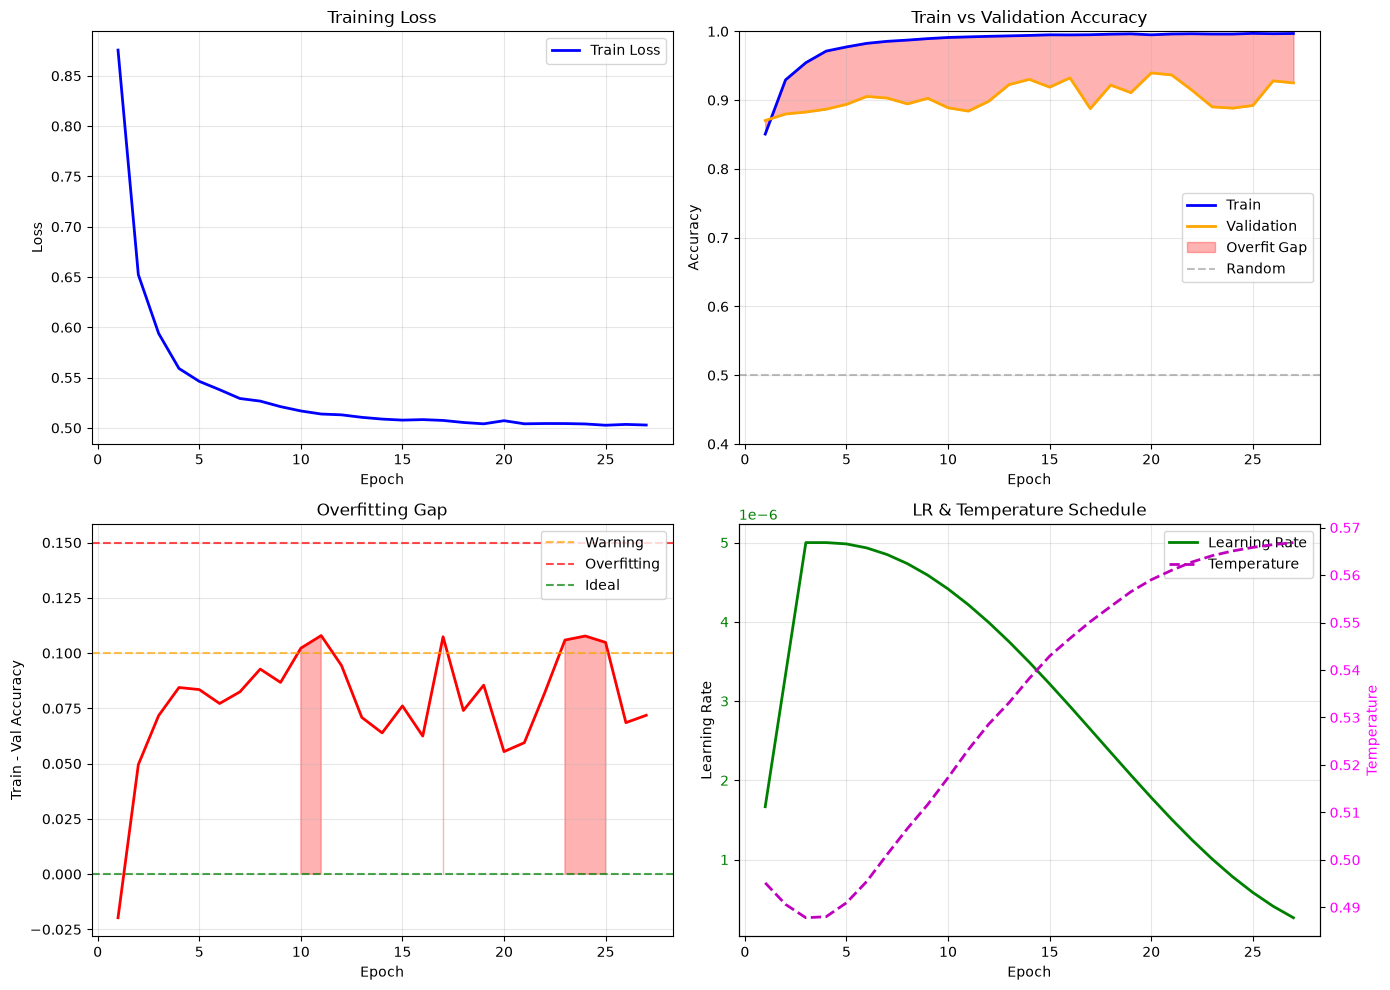

  Saved to C:\Users\admin\Desktop\Amr Samir\FewShot-Fruit-Grade-Classification-trained\Imgs\training_curves.png


In [6]:
plot_training_history(history, config)

## 4 · Evaluate on Unseen Fruits

In [7]:
main_results = test_on_unseen_fruits(model, test_dataset, device, config, n_trials=5)

Testing on unseen fruits...



Overall: 88.2%  +/- 0.2% (episode-level, n=3000)  +/- 0.4% (trial-level, n=5)


## 5 · Embedding Visualisation (t-SNE)

  File "C:\Users\admin\anaconda3\envs\fsgrade\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


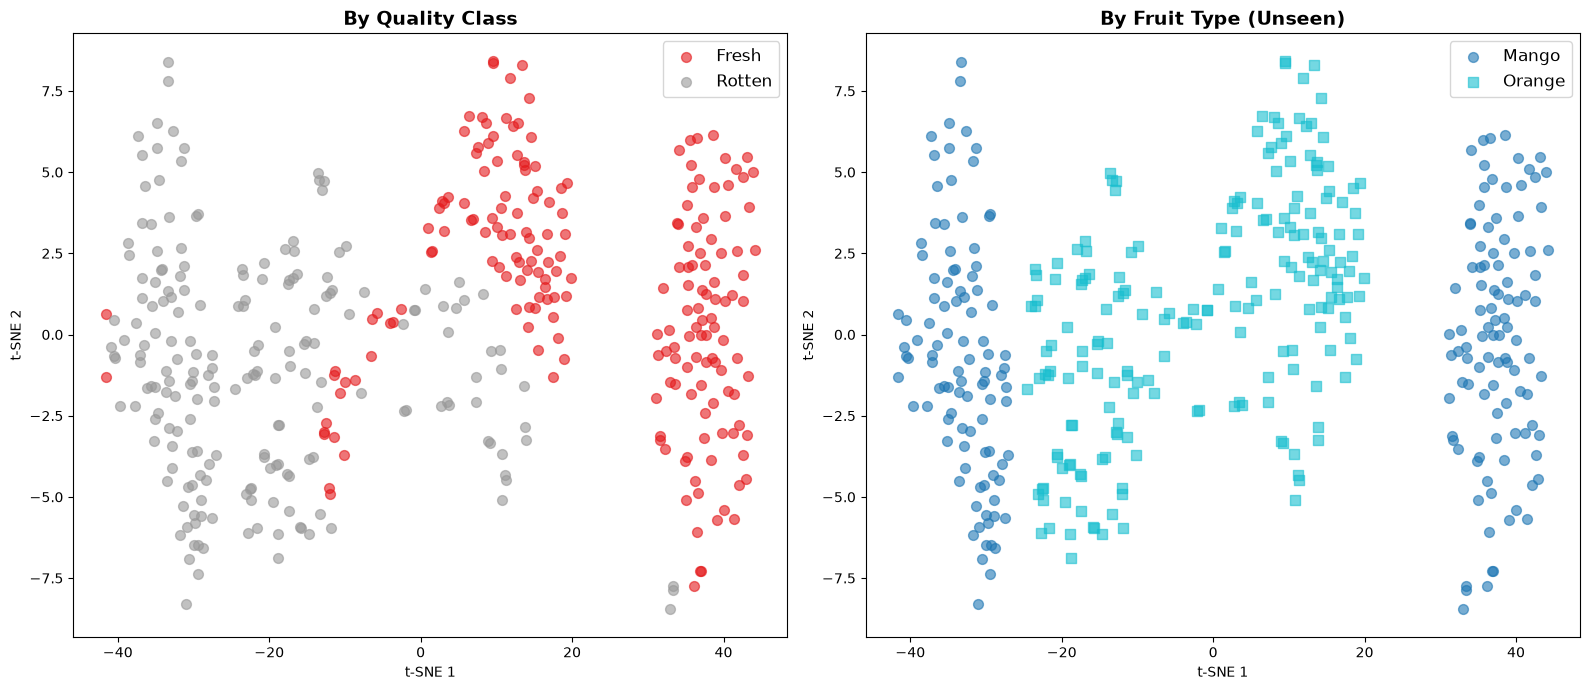

  Silhouette: 0.504  |  5-NN purity: 0.983


In [8]:
emb2d, labels, fruits = visualize_embeddings(
    model, test_dataset, eval_transform, device, config
)

## 6 · Confusion Matrices

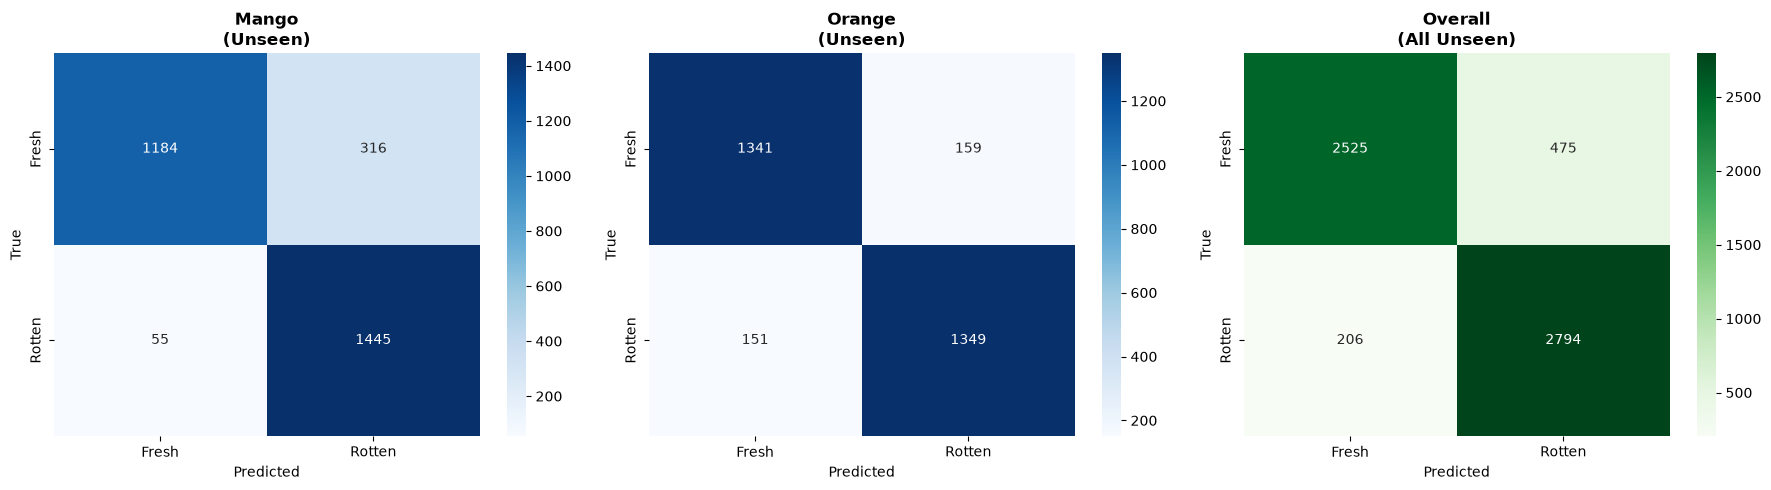


Classification Report (All Unseen Fruits):
              precision    recall  f1-score   support

       Fresh       0.92      0.84      0.88      3000
      Rotten       0.85      0.93      0.89      3000

    accuracy                           0.89      6000
   macro avg       0.89      0.89      0.89      6000
weighted avg       0.89      0.89      0.89      6000


In [9]:
cm = plot_confusion_matrices(model, test_dataset, device, config)

## 7 · N-Shot Ablation Study

Running N-shot ablation study...

  Testing 1-shot...


    1-shot: 86.5% +/- 0.5%

  Testing 3-shot...


    3-shot: 88.3% +/- 0.3%

  Testing 5-shot...


    5-shot: 88.0% +/- 0.9%

  Testing 10-shot...


    10-shot: 88.4% +/- 0.7%


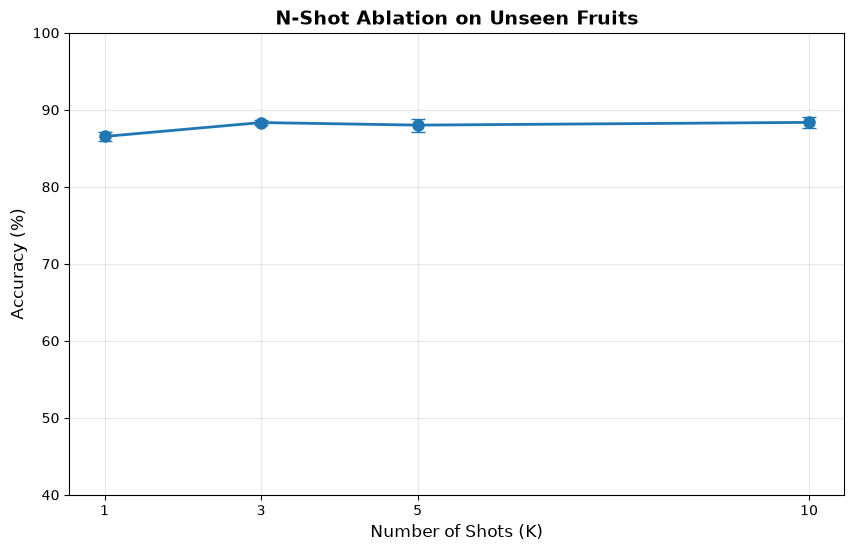

In [10]:
nshot_results = ablation_n_shot(model, test_dataset, device, config)
plot_ablation_nshot(nshot_results, config)

## 8 · Baseline Comparisons

In [11]:
baseline_results = run_all_fsl_baselines(
    model, train_dataset, val_dataset, test_dataset, config, device
)

Computing Nearest Centroid (pixel) baseline...


  Nearest Centroid: 68.9%

  Training baseline: Siamese Network


  Epoch   1 | Train 0.934 | Val 0.804 | Best 0.804


  Epoch   5 | Train 0.984 | Val 0.903 | Best 0.903


  Epoch  10 | Train 0.987 | Val 0.789 | Best 0.903


...

  Epoch   1 | Train 0.958 | Val 0.920 | Best 0.920


  Epoch   5 | Train 0.994 | Val 0.880 | Best 0.920


  Early stopping at epoch 8



  ProtoNet + Temp. Scaling Test Accuracy: 94.5%
    orange: 93.1%
    mango: 96.0%

Evaluating our full model...



  Method                           Accuracy     95% CI
  -------------------------------------------------------
  Nearest Centroid (pixels)           68.9%       0.8%
  Siamese Network                     88.0%       0.7%
  Matching Network                    92.7%       0.5%
  ProtoNet (standard)                 94.7%       0.4%
  ProtoNet + Temp. Scaling            94.5%       0.3%
  Ours (Full Model)                   87.9%       0.5% ***


## 9 · Statistical Significance Tests

In [12]:
sig_table = statistical_significance_tests(baseline_results)

  STATISTICAL SIGNIFICANCE TESTS  (n = 600 episodes)
  Baseline                          delta   t-stat      p (t)   W-stat      p (W)      Outcome
  ------------------------------------------------------------------------------------------
  Nearest Centroid (pixels)        +18.99    40.38  4.23e-173      702   2.12e-98  ours better
  Siamese Network                   -0.19    -0.41   6.80e-01    71194   7.74e-01           ns
  Matching Network                  -4.89   -14.01   8.97e-39    22380   1.37e-38   ours WORSE
  ProtoNet (standard)               -6.82   -22.51   8.77e-82    11988   1.21e-63   ours WORSE
  ProtoNet + Temp. Scaling          -6.67   -22.30   1.13e-80    10015   1.00e-64   ours WORSE


## 10 · Backbone Ablation

In [13]:
backbone_results = backbone_ablation(
    train_dataset, val_dataset, test_dataset, config, device
)


  Backbone Ablation: resnet18


  Epoch 5 | Train 0.984 | Val 0.909


  Epoch 10 | Train 0.993 | Val 0.890


  Epoch 15 | Train 0.995 | Val 0.908


  Epoch 20 | Train 0.996 | Val 0.926


...

  resnet50: 95.5% +/- 0.3%
    orange: 95.6%
    mango: 95.3%

  Backbone Ablation: efficientnet_b0


  Epoch 5 | Train 0.970 | Val 0.878


  Epoch 10 | Train 0.982 | Val 0.862


  Early stopping at epoch 14


  efficientnet_b0: 85.3% +/- 0.6%
    orange: 88.7%
    mango: 81.8%

  BACKBONE ABLATION SUMMARY
  Backbone               Accuracy     95% CI          Params
  ------------------------------------------------------------
  resnet18                  89.0%       0.5%   11,414,017
  resnet50                  95.5%       0.3%   24,464,129
  efficientnet_b0           85.3%       0.6%    4,793,397


## 11 · Single-Species Baselines

In [14]:
single_sp_results = run_single_species_baselines(
    model, test_dataset, transforms_dict, config, device
)


  SINGLE-SPECIES BASELINES (Table 4)

  Training on [apple] only ...
  [train] Loaded  651 images: apple/fresh
  [train] Loaded  536 images: apple/rotten
  [val  ] Loaded  114 images: apple/fresh
  [val  ] Loaded   94 images: apple/rotten


    apple-trained -> unseen: 90.5% +/- 0.4%

  Training on [banana] only ...
  [train] Loaded  637 images: banana/fresh
  [train] Loaded  538 images: banana/rotten
  [val  ] Loaded  112 images: banana/fresh
  [val  ] Loaded   94 images: banana/rotten


    Early stopping at epoch 8


    banana-trained -> unseen: 91.7% +/- 0.4%

  Training on [grape] only ...
  [train] Loaded  655 images: grape/fresh
  [train] Loaded  536 images: grape/rotten
  [val  ] Loaded  115 images: grape/fresh
  [val  ] Loaded   94 images: grape/rotten


    Early stopping at epoch 19


    grape-trained -> unseen: 72.6% +/- 1.4%



  Training Species            Accuracy     95% CI
  --------------------------------------------------
  Apple-trained                  90.5%       0.4%
  Banana-trained                 91.7%       0.4%
  Grape-trained                  72.6%       1.4%
  Multi-species (Ours)           88.2%       0.5% ***


## 12 · Species-Split Cross-Validation

In [15]:
cv_results = species_split_cross_validation(transforms_dict, config, device)


  Split 1/10: Train=['apple', 'banana', 'grape'], Test=['mango', 'orange']
  [train] Loaded  651 images: apple/fresh
  [train] Loaded  536 images: apple/rotten
  [train] Loaded  637 images: banana/fresh
  [train] Loaded  538 images: banana/rotten
  [train] Loaded  655 images: grape/fresh
  [train] Loaded  536 images: grape/rotten
  [val  ] Loaded  114 images: apple/fresh
  [val  ] Loaded   94 images: apple/rotten
  [val  ] Loaded  112 images: banana/fresh
  [val  ] Loaded   94 images: banana/rotten
  [val  ] Loaded  115 images: grape/fresh
  [val  ] Loaded   94 images: grape/rotten
  [all  ] Loaded  763 images: mango/fresh
  [all  ] Loaded  630 images: mango/rotten
  [all  ] Loaded  753 images: orange/fresh
  [all  ] Loaded  656 images: orange/rotten


  Early stopping at epoch 13


  Result: 93.1% +/- 0.4%

  Split 2/10: Train=['apple', 'banana', 'mango'], Test=['grape', 'orange']
  [train] Loaded  651 images: apple/fresh
  [train] Loaded  536 images: apple/rotten
  [train] Loaded  637 images: banana/fresh
  [train] Loaded  538 images: banana/rotten
  [train] Loaded  649 images: mango/fresh
  [train] Loaded  536 images: mango/rotten
  [val  ] Loaded  114 images: apple/fresh
  [val  ] Loaded   94 images: apple/rotten
  [val  ] Loaded  112 images: banana/fresh
  [val  ] Loaded   94 images: banana/rotten
  [val  ] Loaded  114 images: mango/fresh
  [val  ] Loaded   94 images: mango/rotten
  [all  ] Loaded  770 images: grape/fresh
  [all  ] Loaded  630 images: grape/rotten
  [all  ] Loaded  753 images: orange/fresh
  [all  ] Loaded  656 images: orange/rotten


  Result: 78.3% +/- 1.0%

  Split 3/10: Train=['apple', 'banana', 'orange'], Test=['grape', 'mango']
  [train] Loaded  651 images: apple/fresh
  [train] Loaded  536 images: apple/rotten
  [train] Loaded  637 images: banana/fresh
  [train] Loaded  538 images: banana/rotten
  [train] Loaded  641 images: orange/fresh
  [train] Loaded  558 images: orange/rotten
  [val  ] Loaded  114 images: apple/fresh
  [val  ] Loaded   94 images: apple/rotten
  [val  ] Loaded  112 images: banana/fresh
  [val  ] Loaded   94 images: banana/rotten
  [val  ] Loaded  112 images: orange/fresh
  [val  ] Loaded   98 images: orange/rotten
  [all  ] Loaded  770 images: grape/fresh
  [all  ] Loaded  630 images: grape/rotten
  [all  ] Loaded  763 images: mango/fresh
  [all  ] Loaded  630 images: mango/rotten


  Early stopping at epoch 11


...

  Result: 71.8% +/- 0.8%

  Split 9/10: Train=['banana', 'mango', 'orange'], Test=['apple', 'grape']
  [train] Loaded  637 images: banana/fresh
  [train] Loaded  538 images: banana/rotten
  [train] Loaded  649 images: mango/fresh
  [train] Loaded  536 images: mango/rotten
  [train] Loaded  641 images: orange/fresh
  [train] Loaded  558 images: orange/rotten
  [val  ] Loaded  112 images: banana/fresh
  [val  ] Loaded   94 images: banana/rotten
  [val  ] Loaded  114 images: mango/fresh
  [val  ] Loaded   94 images: mango/rotten
  [val  ] Loaded  112 images: orange/fresh
  [val  ] Loaded   98 images: orange/rotten
  [all  ] Loaded  765 images: apple/fresh
  [all  ] Loaded  630 images: apple/rotten
  [all  ] Loaded  770 images: grape/fresh
  [all  ] Loaded  630 images: grape/rotten


  Early stopping at epoch 12


  Result: 73.5% +/- 0.8%

  Split 10/10: Train=['grape', 'mango', 'orange'], Test=['apple', 'banana']
  [train] Loaded  655 images: grape/fresh
  [train] Loaded  536 images: grape/rotten
  [train] Loaded  649 images: mango/fresh
  [train] Loaded  536 images: mango/rotten
  [train] Loaded  641 images: orange/fresh
  [train] Loaded  558 images: orange/rotten
  [val  ] Loaded  115 images: grape/fresh
  [val  ] Loaded   94 images: grape/rotten
  [val  ] Loaded  114 images: mango/fresh
  [val  ] Loaded   94 images: mango/rotten
  [val  ] Loaded  112 images: orange/fresh
  [val  ] Loaded   98 images: orange/rotten
  [all  ] Loaded  765 images: apple/fresh
  [all  ] Loaded  630 images: apple/rotten
  [all  ] Loaded  749 images: banana/fresh
  [all  ] Loaded  632 images: banana/rotten


  Early stopping at epoch 20


  Result: 73.2% +/- 0.9%

  SPECIES SPLIT CROSS-VALIDATION SUMMARY
  Train Species                       Test Species              Acc       CI
  ----------------------------------------------------------------------
  Apple, Banana, Grape                Mango, Orange           93.1%     0.4%
  Apple, Banana, Mango                Grape, Orange           78.3%     1.0%
  Apple, Banana, Orange               Grape, Mango            84.3%     1.0%
  Apple, Grape, Mango                 Banana, Orange          86.6%     0.6%
  Apple, Grape, Orange                Banana, Mango           78.1%     0.6%
  Apple, Mango, Orange                Banana, Grape           79.2%     1.1%
  Banana, Grape, Mango                Apple, Orange           79.7%     1.3%
  Banana, Grape, Orange               Apple, Mango            71.8%     0.8%
  Banana, Mango, Orange               Apple, Grape            73.5%     0.8%
  Grape, Mango, Orange                Apple, Banana           73.2%     0.9%

  Mean acros

## 13 · Component Ablation Study

In [16]:
ablation_results = component_ablation(
    model, train_dataset, val_dataset, test_dataset, config, device
)


  COMPONENT ABLATION STUDY (Table 6)

  Evaluating full model (reference) ...



  -- - Contrastive Loss --


    - Contrastive Loss: 90.8% +/- 0.5%

  -- - Temperature Scaling --


    Early stopping at epoch 17


    - Temperature Scaling: 89.1% +/- 0.4%

  -- - Frozen Layers --


    Early stopping at epoch 14


    - Frozen Layers: 92.7% +/- 0.4%

  -- - Dropout --


    Early stopping at epoch 15


    - Dropout: 89.3% +/- 0.4%

  COMPONENT ABLATION SUMMARY (Table 6)
  Variant                          Accuracy     95% CI    Delta
  ------------------------------------------------------------
  Full Model                          88.2%       0.5%      ---
  - Contrastive Loss                  90.8%       0.5%     +2.6
  - Temperature Scaling               89.1%       0.4%     +1.0
  - Frozen Layers                     92.7%       0.4%     +4.5
  - Dropout                           89.3%       0.4%     +1.2


## 14 · Thesis Summary & LaTeX Tables

In [17]:
all_results = {
    'main_experiment': main_results,
    'ablation_nshot':  nshot_results,
    'baselines':       baseline_results,
}

generate_thesis_summary(all_results, dataset_stats, config)
generate_latex_tables(all_results, config)

COMPLETE THESIS RESULTS SUMMARY

--------------------------------------------------------------------------------
1. RESEARCH FOCUS
--------------------------------------------------------------------------------
  Task: Cross-Species Fruit Quality Grading
  Problem: Binary classification (Fresh vs Rotten) that generalizes to unseen fruits
  Method: Few-Shot Learning with Prototypical Networks
  Key Claim: Model trained on {Apple, Banana, Grape} generalizes to {Mango, Orange}

--------------------------------------------------------------------------------
2. DATASET STATISTICS
--------------------------------------------------------------------------------
  Training Fruits (Seen): ['apple', 'banana', 'grape']
  Test Fruits (Unseen):   ['mango', 'orange']
  Classes: Fresh vs Rotten
  Total Training Images:  4176
  Total Test Images:      2802

--------------------------------------------------------------------------------
3. MAIN RESULTS: Cross-Species Generalization
----------------

## 15 · Persist every result to JSON

`RUNBOOK.md` §1 objects that "no code in it ever wrote `results/*.json`", so the numbers
this notebook printed could never be regenerated or audited. This cell closes that gap:
every result object produced above is written to `results/notebook_metrics.json`,
keyed to match `scripts/reproduce_thesis.py`'s `metrics.json` so the two runs can be
compared mechanically rather than by eye.

In [18]:
import json, platform, subprocess, datetime


class _NumpyEncoder(json.JSONEncoder):
    """Same contract as reproduce_thesis.py's NumpyEncoder."""
    def default(self, o):
        if isinstance(o, np.integer):
            return int(o)
        if isinstance(o, np.floating):
            return float(o)
        if isinstance(o, np.ndarray):
            return o.tolist()
        if isinstance(o, np.bool_):
            return bool(o)
        if isinstance(o, (set, tuple)):
            return list(o)
        return str(o)


def _git_head():
    try:
        return subprocess.check_output(
            ['git', 'rev-parse', 'HEAD'], cwd=REPO_ROOT, text=True).strip()
    except Exception:
        return None


# Keys mirror reproduce_thesis.py's metrics.json where the same quantity exists,
# so the notebook run and the script runs can be diffed key by key.
_WANTED = {
    'dataset':            'dataset_stats',
    'training_history':   'history',
    'cross_species':      'main_results',
    'confusion':          'cm',
    'nshot_ablation':     'nshot_results',
    'baselines':          'baseline_results',
    'significance':       'sig_table',
    'backbone_ablation':  'backbone_results',
    'single_species':     'single_sp_results',
    'species_cv':         'cv_results',
    'component_ablation': 'ablation_results',
}

notebook_metrics = {
    'source': 'notebooks/main_experiment.ipynb',
    'produced_at': datetime.datetime.now().isoformat(timespec='seconds'),
    'git_head': _git_head(),
    'seed': 42,
    'env': {
        'python': platform.python_version(),
        'torch': torch.__version__,
        'cuda_available': torch.cuda.is_available(),
        'device': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu',
        'numpy': np.__version__,
    },
    'config': {k: getattr(config, k) for k in dir(config)
               if k.isupper() and not k.startswith('_')},
    'model': {
        'total_params': int(sum(p.numel() for p in model.parameters())),
        'trainable_params': int(sum(p.numel() for p in model.parameters()
                                    if p.requires_grad)),
        'learned_temperature': float(model.temperature.detach().cpu()),
    },
}

_missing = []
for out_key, var_name in _WANTED.items():
    if var_name in globals() and globals()[var_name] is not None:
        notebook_metrics[out_key] = globals()[var_name]
    else:
        _missing.append(f'{out_key} (<- {var_name})')

# The t-SNE projection, kept so the embedding figure can be redrawn without
# re-running the model.
if 'emb2d' in globals():
    notebook_metrics['embedding_tsne'] = {
        'points': emb2d, 'labels': labels, 'fruits': fruits,
    }

_out = os.path.join(config.RESULTS_DIR, 'notebook_metrics.json')
os.makedirs(config.RESULTS_DIR, exist_ok=True)
with open(_out, 'w', encoding='utf-8') as fh:
    json.dump(notebook_metrics, fh, indent=2, cls=_NumpyEncoder)

print(f'Wrote {_out}')
print(f'  {os.path.getsize(_out) / 1024:.1f} KB, {len(notebook_metrics)} top-level keys')
if _missing:
    print(f'  MISSING (cell did not run or returned None): {", ".join(_missing)}')
else:
    print('  All expected result objects captured.')

_o = notebook_metrics.get('cross_species', {}).get('overall', {})
if _o:
    print(f"\n  Headline cross-species accuracy: {_o.get('mean', float('nan')) * 100:.2f}%")
    print(f"    ci_95_episode {_o.get('ci_95_episode', float('nan')) * 100:.2f}% "
          f"(n={_o.get('n_episodes')})")
    print(f"    ci_95_trial   {_o.get('ci_95_trial', float('nan')) * 100:.2f}% "
          f"(n={_o.get('n_trials')})")

Wrote C:\Users\admin\Desktop\Amr Samir\FewShot-Fruit-Grade-Classification-trained\results\notebook_metrics.json
  377.2 KB, 19 top-level keys
  All expected result objects captured.

  Headline cross-species accuracy: 88.18%
    ci_95_episode 0.21% (n=3000)
    ci_95_trial   0.39% (n=5)
